# The purpose of this notebook is to understnad how the emcee sampler works so that I can fit some TDE lightcurves for t_peak as wekk as some other goodies

### Environment: Rosohna 


100%|██████████| 1000/1000 [00:00<00:00, 2624.90it/s]


saved diagnostics.png
saved diagnostics_corner.png


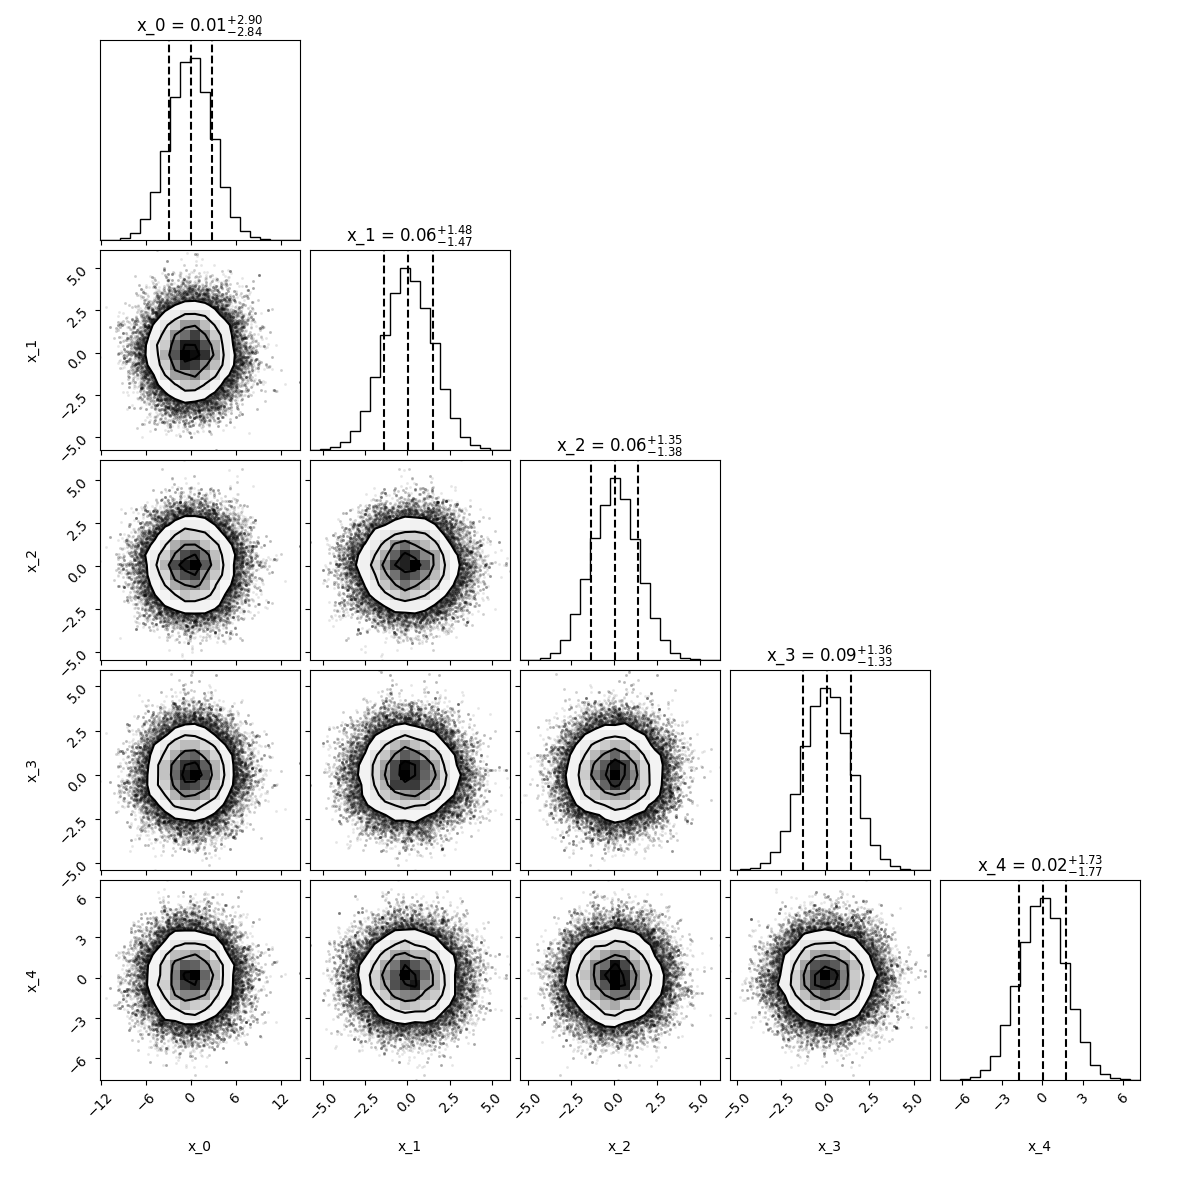

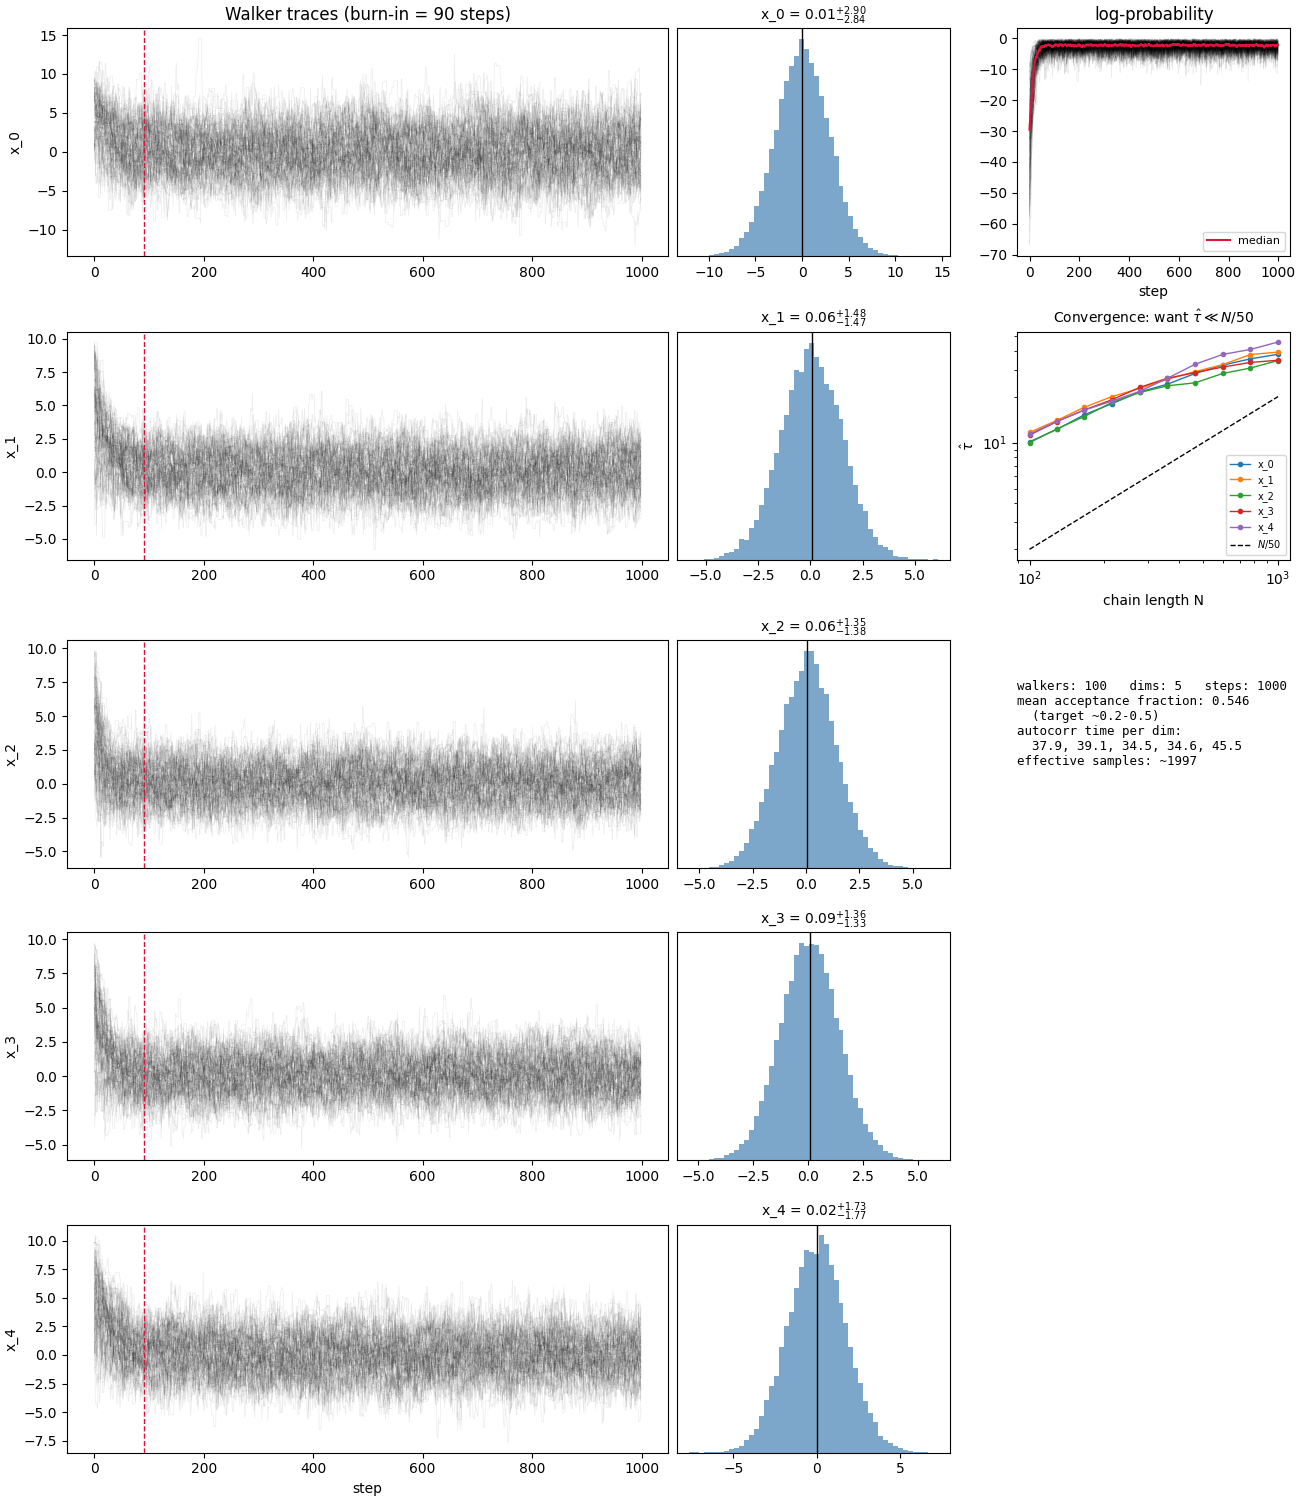

In [14]:
#emcee hello world

import numpy as np
import emcee
import matplotlib.pyplot as plt
%matplotlib widget
import corner

def log_probability(x, variance):
    return -0.5 * np.sum(x ** 2 / variance)

ndim, nwalkers = 5, 100
variance = np.random.rand(ndim) * 10

prior = np.random.rand(nwalkers, ndim) * 10

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=[variance])
sampler.run_mcmc(prior, 1000, progress=True)

#asking claude for code to visualize the progress of the fit
def plot_diagnostics(sampler, burnin=None, labels=None, savefig=None):
    """
    Parameters
    ----------
    sampler : emcee.EnsembleSampler (already run)
    burnin  : int, steps to discard. Defaults to 2x the autocorrelation
              time if it can be estimated, else 25% of the chain.
    labels  : list of str, parameter names
    savefig : str, path to save the figure (optional)
    """
    chain = sampler.get_chain()                # (nsteps, nwalkers, ndim)
    log_prob = sampler.get_log_prob()          # (nsteps, nwalkers)
    nsteps, nwalkers, ndim = chain.shape
    if labels is None:
        labels = [f"$x_{{{i}}}$" for i in range(ndim)]
 
    # --- autocorrelation time ---
    try:
        tau = sampler.get_autocorr_time(tol=0)
        tau_max = int(np.nanmax(tau))
    except Exception:
        tau, tau_max = None, None
 
    if burnin is None:
        burnin = 2 * tau_max if tau_max else nsteps // 4
    flat = sampler.get_chain(discard=burnin, flat=True)
 
    # --- figure ---
    fig = plt.figure(figsize=(13, 3 * ndim), constrained_layout=True)
    gs = fig.add_gridspec(ndim, 3, width_ratios=[2.2, 1, 1])
 
    # 1. trace plots
    for i in range(ndim):
        ax = fig.add_subplot(gs[i, 0])
        ax.plot(chain[:, :, i], color="k", alpha=0.08, lw=0.5)
        ax.axvline(burnin, color="crimson", ls="--", lw=1)
        ax.set_ylabel(labels[i])
        if i == 0:
            ax.set_title(f"Walker traces (burn-in = {burnin} steps)")
        if i == ndim - 1:
            ax.set_xlabel("step")
 
    # 2. marginal posteriors
    for i in range(ndim):
        ax = fig.add_subplot(gs[i, 1])
        ax.hist(flat[:, i], bins=50, color="steelblue", histtype="stepfilled", alpha=0.7)
        med = np.median(flat[:, i])
        lo, hi = np.percentile(flat[:, i], [16, 84])
        ax.axvline(med, color="k", lw=1)
        ax.set_title(f"{labels[i]} = {med:.2f}$^{{+{hi-med:.2f}}}_{{-{med-lo:.2f}}}$", fontsize=10)
        ax.set_yticks([])
 
    # 3a. log-prob evolution (top-right block)
    ax = fig.add_subplot(gs[0, 2])
    ax.plot(log_prob, color="k", alpha=0.08, lw=0.5)
    ax.plot(np.median(log_prob, axis=1), color="crimson", lw=1.5, label="median")
    ax.set_title("log-probability")
    ax.set_xlabel("step")
    ax.legend(fontsize=8)
 
    # 3b. autocorrelation growth check
    ax = fig.add_subplot(gs[1, 2])
    N = np.unique(np.geomspace(100, nsteps, 10).astype(int))
    for i in range(ndim):
        taus = []
        for n in N:
            try:
                import emcee
                t = emcee.autocorr.integrated_time(chain[:n, :, i], tol=0)
                taus.append(t[0])
            except Exception:
                taus.append(np.nan)
        ax.loglog(N, taus, "o-", ms=3, lw=1, label=labels[i])
    ax.loglog(N, N / 50, "k--", lw=1, label=r"$N/50$")
    ax.set_xlabel("chain length N")
    ax.set_ylabel(r"$\hat{\tau}$")
    ax.set_title("Convergence: want $\\hat{\\tau} \\ll N/50$", fontsize=10)
    ax.legend(fontsize=7)
 
    # 3c. summary text panel
    ax = fig.add_subplot(gs[2:, 2]) if ndim > 2 else fig.add_subplot(gs[-1, 2])
    ax.axis("off")
    acc = np.mean(sampler.acceptance_fraction)
    lines = [
        f"walkers: {nwalkers}   dims: {ndim}   steps: {nsteps}",
        f"mean acceptance fraction: {acc:.3f}",
        "  (target ~0.2-0.5)",
    ]
    if tau is not None:
        lines.append("autocorr time per dim:")
        lines.append("  " + ", ".join(f"{t:.1f}" for t in tau))
        lines.append(f"effective samples: ~{int(flat.shape[0] / np.nanmax(tau))}")
    else:
        lines.append("autocorr time: chain too short to estimate")
    ax.text(0.0, 0.95, "\n".join(lines), va="top", family="monospace", fontsize=9)
 
    if savefig:
        fig.savefig(savefig, dpi=150)
        print(f"saved {savefig}")
 

    fig2 = corner.corner(flat, labels=labels, quantiles=[0.16, 0.5, 0.84],
                            show_titles=True, title_fmt=".2f")
    if savefig:
        out2 = savefig.replace(".png", "_corner.png")
        fig2.savefig(out2, dpi=150)
        print(f"saved {out2}")
 
    plt.show()

plot_diagnostics(sampler, labels=[f"x_{i}" for i in range(ndim)], savefig="diagnostics.png")

In [9]:
# real fast let's implement our own version of metropolis hastings to compare with emcee (and so that I can rmeeber how MCMC works properly). 
# This is D. Foreman-Mackey's advice in the emcee paper, to be done before downloading emcee 

class MH_Sampler:
    """
    Example of a simple Metropolis-Hastings sampler for a given log-probability function. 
    """

    def __init__(self, log_prob_func, ndim, prior=None, proposal_width=1.0, args=None):
        """
        Initialize the sampler with the log-probability function, number of dimensions, prior, and proposal width.

        Args:
            log_prob_func (callable): Function that computes the log-probability of a given parameter vector.
            ndim (int): Number of dimensions in the parameter space.
            prior (array-like, optional): Prior mean for the parameters. Defaults to zero vector if not provided.
            proposal_width (float, optional): Standard deviation of the Gaussian proposal distribution. Defaults to 1.0.
        Returns:
            None
        """
        if args is not None:
            self.log_prob_func = lambda x: log_prob_func(x, *args)
        else:
            self.log_prob_func = log_prob_func
        self.ndim = ndim
        self.prior = prior if prior is not None else np.zeros(ndim)
        self.proposal_width = proposal_width
        self.chain = []
        self.accepted = 0
        self.total = 0

    def sample(self, nsteps, proposal_width=1.0, start_from_prior=True):
        """
        Run the Metropolis-Hastings sampling algorithm.

        Args:
            nsteps (int): Number of steps to run the sampler.
            proposal_width (float, optional): Standard deviation of the Gaussian proposal distribution. Defaults to 1.0.
            start_from_prior (bool, optional): Whether to start sampling from the prior or from the last point in the chain. Defaults to True.

        Returns:
            np.ndarray: Array containing the sampled parameter vectors.
        """

        #ability to start from a prior or from the last point in the chain
        if start_from_prior:
            current = self.prior
        else:
            current = self.chain[-1]

        current_log_prob = self.log_prob_func(current)
        if start_from_prior or self.chain == []:
            self.chain.append(current)

        for _ in range(nsteps):
            proposal = current + np.random.normal(0, proposal_width, size=self.ndim)
            proposal_log_prob = self.log_prob_func(proposal)

            # Metropolis-Hastings acceptance criterion
            if np.log(np.random.rand()) < proposal_log_prob - current_log_prob:
                current = proposal
                current_log_prob = proposal_log_prob
                self.accepted += 1

            self.chain.append(current)
            self.total += 1

        return np.array(self.chain)
    
# let's test our MH_Sampler with the same log_probability function and variance as before
mh_sampler = MH_Sampler(log_probability, ndim, prior=np.zeros(ndim), proposal_width=1.0, args=[variance])
mh_chain = mh_sampler.sample(nsteps=1000, proposal_width=1.0, start_from_prior=True)

 param |  tau_emcee   tau_MH |  ESS_emcee   ESS_MH
----------------------------------------------------
    x0 |       39.1     55.7 |       2556       18
    x1 |       39.2     17.9 |       2552       56
    x2 |       37.4     41.9 |       2673       24
    x3 |       27.1     11.4 |       3693       88
    x4 |       36.9     76.8 |       2711       13
----------------------------------------------------
  mean |       35.9     40.7

likelihood evals:  emcee 100,000   MH 1,001
ESS per eval (min dim):  emcee 0.0255   MH 0.0130   (emcee 2.0x)


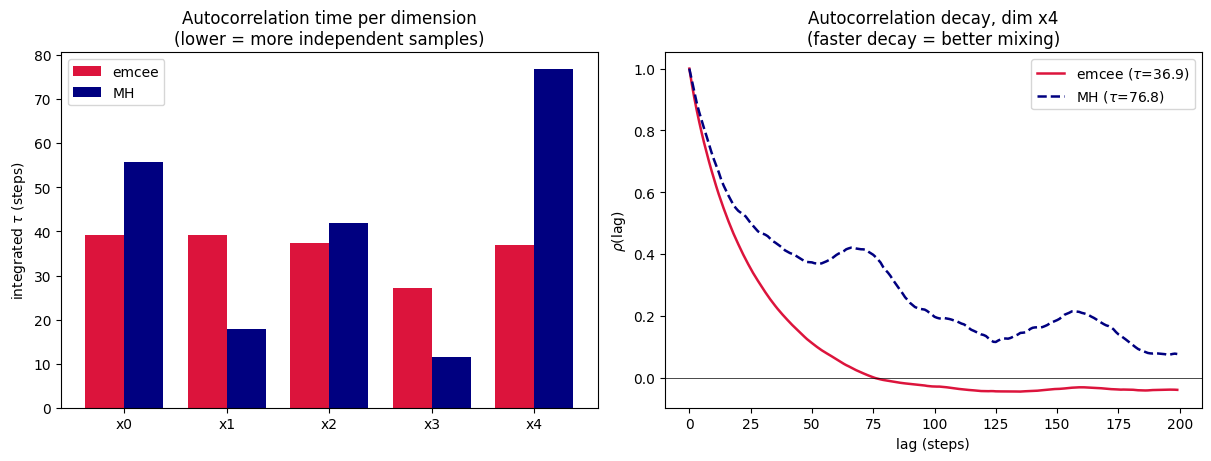

{'tau_emcee': array([39.12164899, 39.19103684, 37.41248051, 27.07767739, 36.88144327]),
 'tau_mh': array([55.67722603, 17.87409551, 41.94752097, 11.41159527, 76.77975609]),
 'ess_emcee': array([2556.12947291, 2551.60383764, 2672.90483365, 3693.07893636,
        2711.39063797]),
 'ess_mh': array([17.97862558, 56.00283378, 23.86315036, 87.7177972 , 13.0372907 ]),
 'evals_emcee': 100000,
 'evals_mh': 1001,
 'eff_per_eval_emcee': np.float64(0.025516038376410453),
 'eff_per_eval_mh': np.float64(0.013024266432608235)}

In [10]:
# compare the results of the MH_Sampler with emcee, using visualizaiton and autocorrelation code Claude wrote

def _acf_ensemble(chain_2d):
    """Mean normalized ACF across walkers. chain_2d: (nsteps, nwalkers)."""
    acfs = [emcee.autocorr.function_1d(chain_2d[:, w]) for w in range(chain_2d.shape[1])]
    return np.mean(acfs, axis=0)
 
 
def compare_autocorr(emcee_out, mh_chain, labels=None, tol=0, verbose=True,
                     plot=False, savefig=None):
    """
    Parameters
    ----------
    emcee_out : emcee.EnsembleSampler (post-run) OR a chain array of shape
                (nsteps, nwalkers, ndim) from sampler.get_chain().
    mh_chain  : ndarray (nsteps, ndim) as returned by MH_Sampler.sample().
    labels    : list of parameter names (optional).
    tol       : passed to emcee.autocorr.integrated_time. Use 0 to always get a
                number; the default 50 raises if the chain is < 50*tau long.
    verbose   : print the comparison table.
    plot      : if True, draw two panels: per-dimension tau (emcee vs MH) and
                the autocorrelation-function decay for the dimension MH mixes
                worst in. Default False (text only).
    savefig   : path to save the figure (only used when plot=True).
 
    Returns
    -------
    dict with keys:
        tau_emcee, tau_mh        : per-dim integrated autocorrelation times
        ess_emcee, ess_mh        : effective sample sizes per dim
        evals_emcee, evals_mh    : total likelihood evaluations
        eff_per_eval_emcee/_mh   : ESS per evaluation (min over dims)
    """
    # --- normalize emcee input to a (nsteps, nwalkers, ndim) array ---
    e_chain = emcee_out.get_chain() if hasattr(emcee_out, "get_chain") else np.asarray(emcee_out)
    if e_chain.ndim != 3:
        raise ValueError("emcee chain must be 3D (nsteps, nwalkers, ndim)")
    nsteps_e, nwalkers, ndim = e_chain.shape
 
    mh_chain = np.asarray(mh_chain)
    if mh_chain.ndim != 2 or mh_chain.shape[1] != ndim:
        raise ValueError(f"mh_chain must be (nsteps, {ndim}); got {mh_chain.shape}")
    nsteps_m = mh_chain.shape[0]
 
    if labels is None:
        labels = [f"x{i}" for i in range(ndim)]
 
    # --- integrated autocorrelation time, per dimension ---
    tau_e = emcee.autocorr.integrated_time(e_chain, tol=tol)
    tau_m = emcee.autocorr.integrated_time(mh_chain.reshape(nsteps_m, 1, ndim), tol=tol)
 
    # --- effective sample size and per-evaluation efficiency ---
    ess_e = nwalkers * nsteps_e / tau_e
    ess_m = nsteps_m / tau_m
    evals_e = nwalkers * nsteps_e
    evals_m = nsteps_m
    eff_e = ess_e.min() / evals_e
    eff_m = ess_m.min() / evals_m
 
    if verbose:
        print(f"{'param':>6} | {'tau_emcee':>10} {'tau_MH':>8} | {'ESS_emcee':>10} {'ESS_MH':>8}")
        print("-" * 52)
        for i in range(ndim):
            print(f"{labels[i]:>6} | {tau_e[i]:>10.1f} {tau_m[i]:>8.1f} | "
                  f"{ess_e[i]:>10.0f} {ess_m[i]:>8.0f}")
        print("-" * 52)
        print(f"{'mean':>6} | {tau_e.mean():>10.1f} {tau_m.mean():>8.1f}")
        print(f"\nlikelihood evals:  emcee {evals_e:,}   MH {evals_m:,}")
        print(f"ESS per eval (min dim):  emcee {eff_e:.4f}   MH {eff_m:.4f}   "
              f"(emcee {eff_e/eff_m:.1f}x)")
 
    if plot:
        import matplotlib.pyplot as plt
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
 
        # left: integrated tau per dimension
        x = np.arange(ndim)
        w = 0.38
        ax1.bar(x - w/2, tau_e, w, color="crimson", label="emcee")
        ax1.bar(x + w/2, tau_m, w, color="navy", label="MH")
        ax1.set_xticks(x)
        ax1.set_xticklabels(labels)
        ax1.set_ylabel(r"integrated $\tau$ (steps)")
        ax1.set_title("Autocorrelation time per dimension\n(lower = more independent samples)")
        ax1.legend()
 
        # right: ACF decay for the dimension MH struggles with most
        d = int(np.argmax(tau_m))
        acf_e = _acf_ensemble(e_chain[:, :, d])
        acf_m = emcee.autocorr.function_1d(mh_chain[:, d])
        L = min(200, nsteps_e, nsteps_m)
        ax2.plot(acf_e[:L], color="crimson", lw=1.8, label=f"emcee ($\\tau$={tau_e[d]:.1f})")
        ax2.plot(acf_m[:L], color="navy", lw=1.8, ls="--", label=f"MH ($\\tau$={tau_m[d]:.1f})")
        ax2.axhline(0, color="k", lw=0.5)
        ax2.set_xlabel("lag (steps)")
        ax2.set_ylabel(r"$\rho(\mathrm{lag})$")
        ax2.set_title(f"Autocorrelation decay, dim {labels[d]}\n(faster decay = better mixing)")
        ax2.legend()
 
        if savefig:
            fig.savefig(savefig, dpi=150)
            print(f"saved {savefig}")
        plt.show()
 
    return dict(tau_emcee=tau_e, tau_mh=tau_m, ess_emcee=ess_e, ess_mh=ess_m,
                evals_emcee=evals_e, evals_mh=evals_m,
                eff_per_eval_emcee=eff_e, eff_per_eval_mh=eff_m)

compare_autocorr(sampler, mh_chain, plot=True)

In [12]:
# sampler.get_autocorr_time()

# emcee quickstart tuorial

In [17]:
#smae idea as above but with a covariance matrix, I'm going to do 3 dimensions so that I can visualize the path around a 3d space

def log_prob(x, mu, cov):
    diff = x - mu
    return -0.5 * np.dot(diff, np.linalg.solve(cov, diff))

ndim = 3

np.random.seed(42)
means = np.random.rand(ndim)

cov = 0.5 - np.random.rand(ndim**2).reshape((ndim, ndim))
cov = np.triu(cov)
cov += cov.T - np.diag(cov.diagonal())
cov = np.dot(cov, cov)

print("Mean:", means)
print("Covariance matrix:\n", cov)

# #make a 3d plot of the distribution of the log probability function
# # --- Claude wrote this ---
# # 3D Gaussian point cloud, colored by distance from origin
# xyz = np.random.default_rng(0).normal(size=(2000, 3))
# r = np.linalg.norm(xyz, axis=1)

# fig = plt.figure(figsize=(7, 6), constrained_layout=True)
# ax = fig.add_subplot(projection="3d")
# p = ax.scatter(*xyz.T, c=r, cmap="viridis", s=8, alpha=0.6)
# fig.colorbar(p, ax=ax, label="r")
# ax.set(xlabel="x", ylabel="y", zlabel="z")
# plt.show()

Mean: [0.37454012 0.95071431 0.73199394]
Covariance matrix:
 [[ 0.24639644 -0.19467857 -0.2303723 ]
 [-0.19467857  0.26263239  0.20287232]
 [-0.2303723   0.20287232  0.34937928]]


In [18]:
n_walkers = 50
prior = np.random.rand(n_walkers, ndim)

sampler = emcee.EnsembleSampler(n_walkers, ndim, log_prob, args=[means, cov])

state = sampler.run_mcmc(prior, 1000, progress=True)

100%|██████████| 1000/1000 [00:00<00:00, 2888.12it/s]


In [19]:
sampler.get_autocorr_time(tol=0)

array([25.74933195, 28.99570736, 24.37853977])

In [20]:
sampler.reset()

In [21]:
sampler.run_mcmc(state, 10000, progress=True)

100%|██████████| 10000/10000 [00:03<00:00, 2962.35it/s]


State([[ 0.56137364  1.12529463  0.85471864]
 [ 0.09773605  0.52566855  0.7535555 ]
 [ 0.27259     0.87493979  0.85299787]
 [ 0.77540716  0.45154809  0.12211227]
 [ 0.73771276  0.78290792  0.25296123]
 [ 0.03229162  0.9632438   1.60298521]
 [ 1.73709932 -0.30117226 -0.75273735]
 [-0.34184612  1.50010332  1.27043604]
 [ 0.51932316  0.87679967  0.68931377]
 [ 0.13889528  0.94068357  1.00047906]
 [ 0.65414675  0.76223743  0.66862417]
 [ 0.04279962  1.40319225  1.23223469]
 [ 0.52495299  0.86027237  0.04563192]
 [ 0.20493615  1.33527794  1.15465131]
 [ 0.07334577  1.3250341   1.10694139]
 [-0.31781024  1.16299716  2.14285364]
 [ 0.25611838  0.26103091  0.55037048]
 [ 0.01886646  1.00229796  0.78859468]
 [-0.81850256  1.98802482  1.91631196]
 [-0.45062171  1.1293944   1.42922586]
 [ 0.50495349  0.76291216  0.77364058]
 [ 0.39650817  1.43441784  1.23281468]
 [ 0.89506532  0.64851382  0.68520028]
 [ 0.28381834  0.62616078  0.30259184]
 [-0.40656072  1.95068044  1.57134929]
 [ 0.49050065  1.37

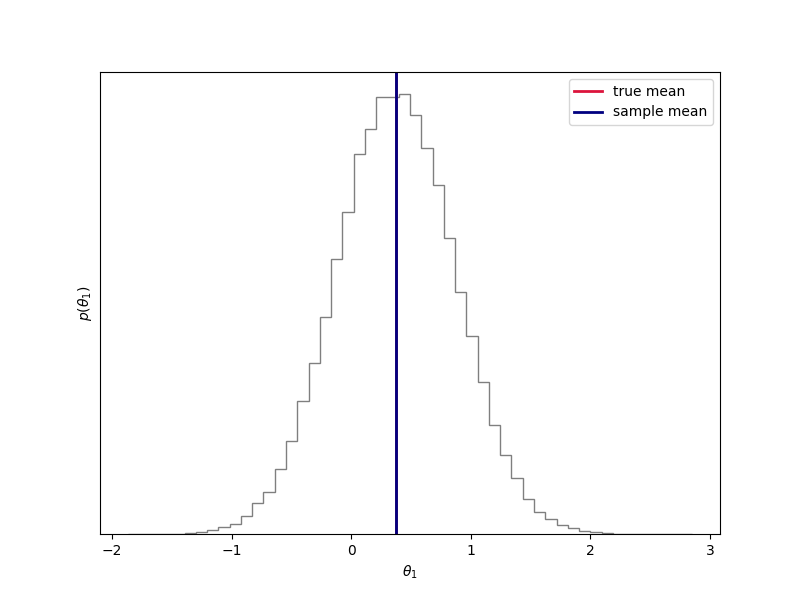

In [36]:
samples = sampler.get_chain(flat=True)
samples[:, 0].shape

plt.figure(figsize=(8, 6))
plt.hist(samples[:, 0], bins=50, density=True, alpha=0.5, color="k", histtype="step")
plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$p(\theta_1)$")
plt.gca().set_yticks([])

#place verticle lines at true mean and mean of samples
plt.axvline(means[0], color="crimson", lw=2, label="true mean")
plt.axvline(np.mean(samples[:, 0]), color="navy", lw=2, label="sample mean")
plt.legend()

In [40]:
#checking acceptance fraction
print(f"Acceptance fraction: {sampler.acceptance_fraction}")
print(f"Mean acceptance fraction: {np.mean(sampler.acceptance_fraction)}")
print("")
print(f"Autocorrelation time: {sampler.get_autocorr_time()}")

Acceptance fraction: [0.6555 0.6548 0.6441 0.6431 0.6423 0.6527 0.6403 0.6475 0.6505 0.6417
 0.644  0.6498 0.6518 0.6482 0.6389 0.6498 0.6494 0.6422 0.6509 0.6432
 0.6451 0.6414 0.6471 0.6417 0.653  0.6452 0.6439 0.6468 0.648  0.6522
 0.6509 0.6479 0.6427 0.6499 0.6467 0.6484 0.6465 0.6486 0.6426 0.6489
 0.6455 0.6476 0.6312 0.6396 0.6516 0.6497 0.6553 0.652  0.649  0.6495]
Mean acceptance fraction: 0.6469840000000001

Autocorrelation time: [40.16384899 40.05204035 38.38908633]


# emcee tutorial #2, fitting a model to data

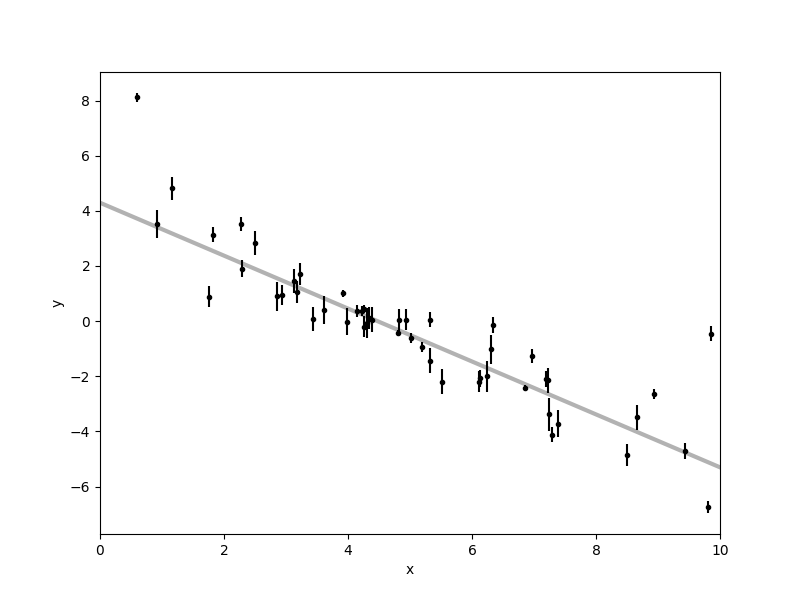

In [41]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(123)

# Choose the "true" parameters.
m_true = -0.9594
b_true = 4.294
f_true = 0.534

# Generate some synthetic data from the model.
N = 50
x = np.sort(10 * np.random.rand(N))
yerr = 0.1 + 0.5 * np.random.rand(N)
y = m_true * x + b_true
y += np.abs(f_true * y) * np.random.randn(N)
y += yerr * np.random.randn(N)

plt.figure(figsize=(8, 6))
plt.errorbar(x, y, yerr=yerr, fmt=".k", capsize=0)
x0 = np.linspace(0, 10, 500)
plt.plot(x0, m_true * x0 + b_true, "k", alpha=0.3, lw=3)
plt.xlim(0, 10)
plt.xlabel("x")
plt.ylabel("y");

Least-squares estimates:
m = -1.104 ± 0.016
b = 5.441 ± 0.091


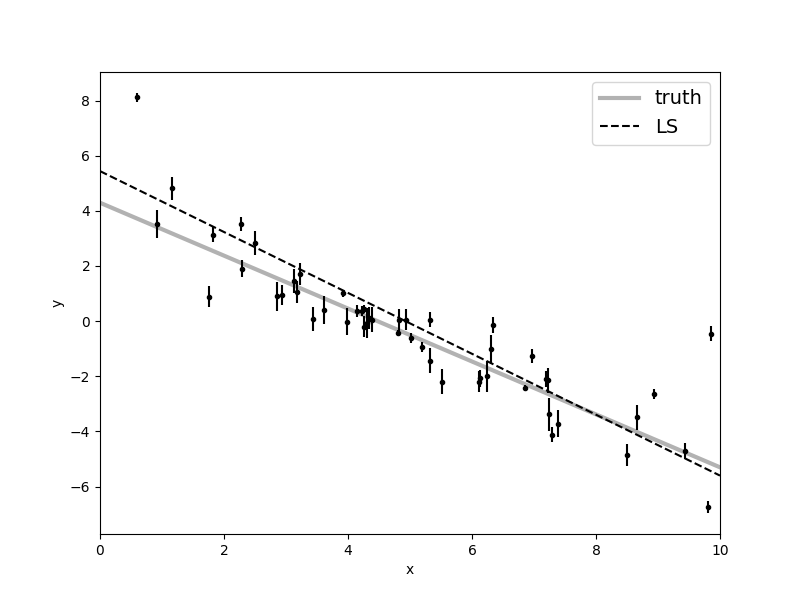

In [42]:
# linear least  squares

A = np.vander(x, 2)
C = np.diag(yerr * yerr)
ATA = np.dot(A.T, A / (yerr**2)[:, None])
cov = np.linalg.inv(ATA)
w = np.linalg.solve(ATA, np.dot(A.T, y / yerr**2))
print("Least-squares estimates:")
print("m = {0:.3f} ± {1:.3f}".format(w[0], np.sqrt(cov[0, 0])))
print("b = {0:.3f} ± {1:.3f}".format(w[1], np.sqrt(cov[1, 1])))

plt.figure(figsize=(8, 6))
plt.errorbar(x, y, yerr=yerr, fmt=".k", capsize=0)
plt.plot(x0, m_true * x0 + b_true, "k", alpha=0.3, lw=3, label="truth")
plt.plot(x0, np.dot(np.vander(x0, 2), w), "--k", label="LS")
plt.legend(fontsize=14)
plt.xlim(0, 10)
plt.xlabel("x")
plt.ylabel("y");


Maximum likelihood estimates:
m = -1.003
b = 4.528
f = 0.454


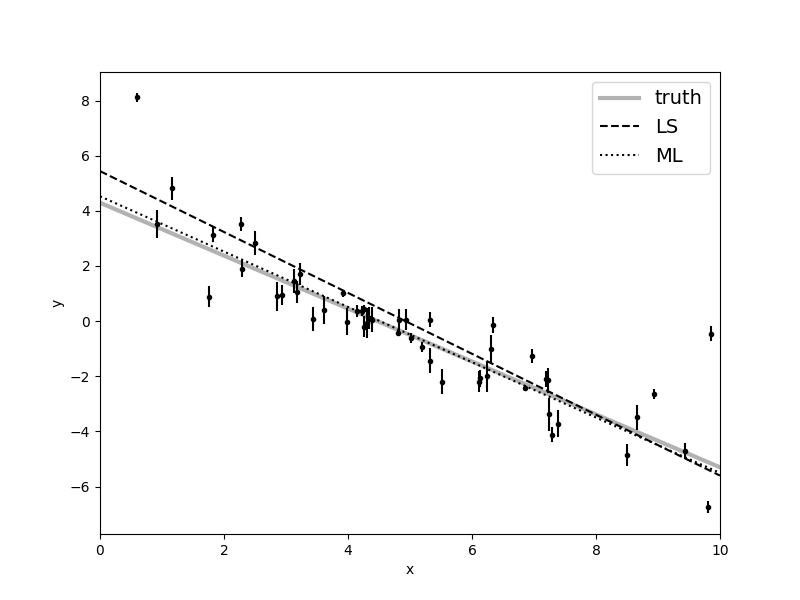

In [43]:
#is this the ln(f) that was referred to in the TDE papers?

#maximum likelihood estimation
def log_likelihood(theta, x, y, yerr):
    m, b, log_f = theta
    model = m * x + b
    sigma2 = yerr**2 + model**2 * np.exp(2 * log_f)
    return -0.5 * np.sum((y - model) ** 2 / sigma2 + np.log(sigma2))

from scipy.optimize import minimize

np.random.seed(42)
nll = lambda *args: -log_likelihood(*args)
initial = np.array([m_true, b_true, np.log(f_true)]) + 0.1 * np.random.randn(3)
soln = minimize(nll, initial, args=(x, y, yerr))
m_ml, b_ml, log_f_ml = soln.x

print("Maximum likelihood estimates:")
print("m = {0:.3f}".format(m_ml))
print("b = {0:.3f}".format(b_ml))
print("f = {0:.3f}".format(np.exp(log_f_ml)))

plt.figure(figsize=(8, 6))
plt.errorbar(x, y, yerr=yerr, fmt=".k", capsize=0)
plt.plot(x0, m_true * x0 + b_true, "k", alpha=0.3, lw=3, label="truth")
plt.plot(x0, np.dot(np.vander(x0, 2), w), "--k", label="LS")
plt.plot(x0, np.dot(np.vander(x0, 2), [m_ml, b_ml]), ":k", label="ML")
plt.legend(fontsize=14)
plt.xlim(0, 10)
plt.xlabel("x")
plt.ylabel("y");

In [44]:
#mcmc needs priors

def log_prior(theta):
    m, b, log_f = theta
    if -5.0 < m < 0.5 and 0.0 < b < 10.0 and -10.0 < log_f < 1.0:
        return 0.0
    return -np.inf

def log_probability(theta, x, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, yerr)

import emcee

pos = soln.x + 1e-4 * np.random.randn(32, 3)
nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(x, y, yerr)
)
sampler.run_mcmc(pos, 5000, progress=True);

100%|██████████| 5000/5000 [00:01<00:00, 3006.50it/s]


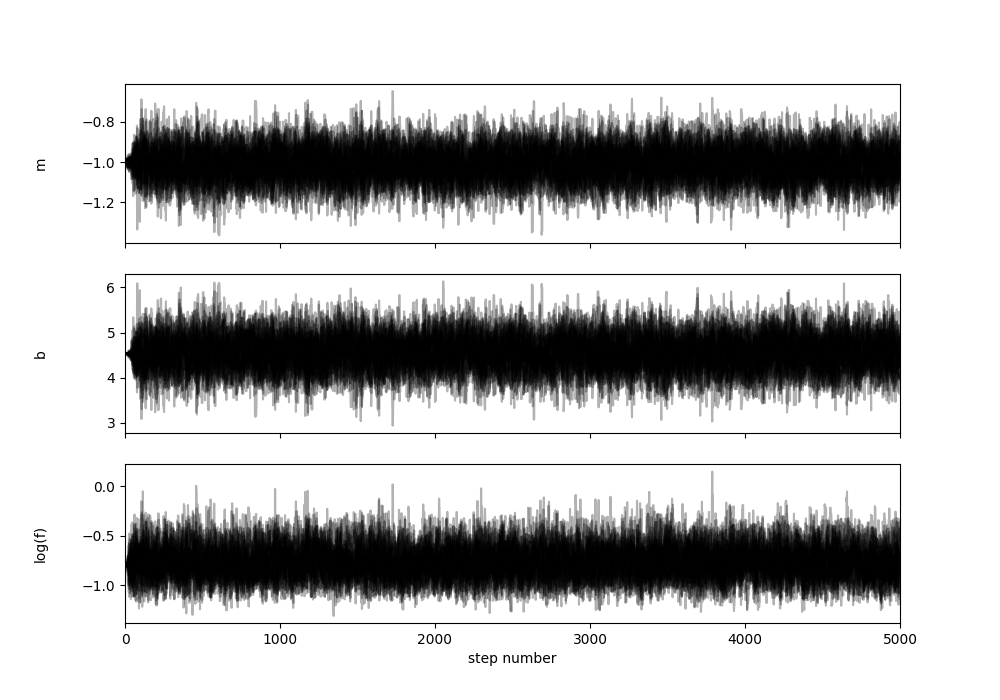

In [45]:
fig, axes = plt.subplots(3, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["m", "b", "log(f)"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

In [46]:
tau = sampler.get_autocorr_time()
print(tau)


[34.35179797 33.78964643 36.77512185]


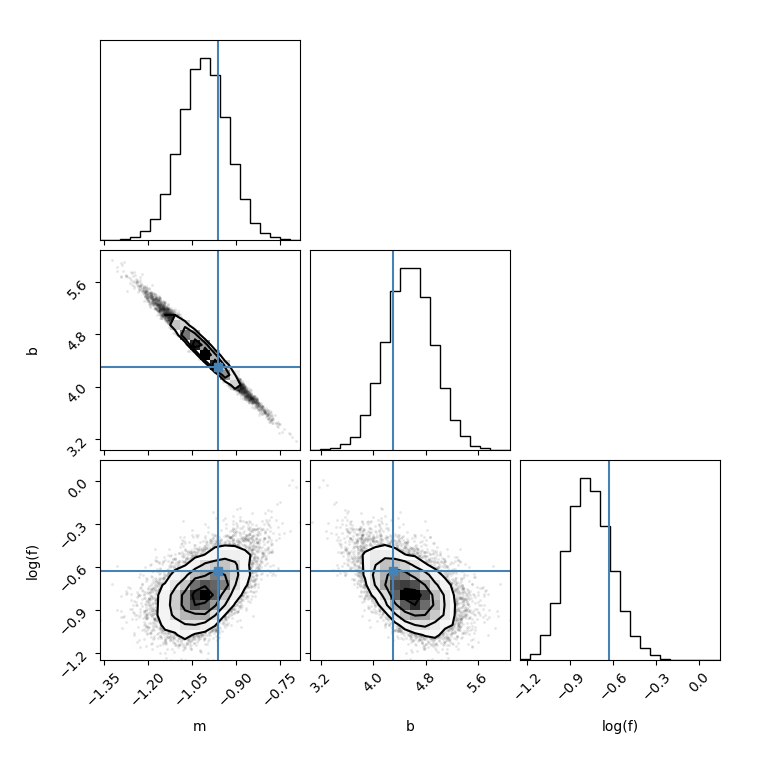

In [48]:
flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)

fig = corner.corner(
    flat_samples, labels=labels, truths=[m_true, b_true, np.log(f_true)]
)

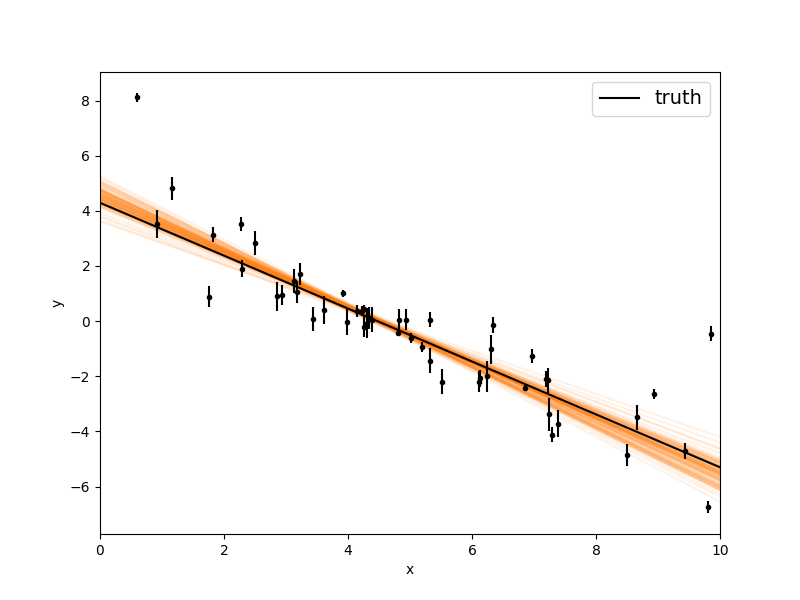

In [49]:
plt.figure(figsize=(8, 6))
inds = np.random.randint(len(flat_samples), size=100)
for ind in inds:
    sample = flat_samples[ind]
    plt.plot(x0, np.dot(np.vander(x0, 2), sample[:2]), "C1", alpha=0.1)
plt.errorbar(x, y, yerr=yerr, fmt=".k", capsize=0)
plt.plot(x0, m_true * x0 + b_true, "k", label="truth")
plt.legend(fontsize=14)
plt.xlim(0, 10)
plt.xlabel("x")
plt.ylabel("y");

In [52]:
from IPython.display import display, Math

for i in range(ndim):
    mcmc = np.percentile(flat_samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], labels[i])
    display(Math(txt))

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/var/folders/k3/l6fjnjt51mv03h22m9cpmzgw0000gn/T/ipykernel_99991/1529384300.py:6: SyntaxWarning: invalid escape sequence '\m'
  txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

# Okay for real this time, let's try fitting some ZTF data

In [110]:
# we'll start by making sure we have functions that can load ZTF data

import numpy as np
import emcee
import matplotlib.pyplot as plt
%matplotlib widget
import corner
from pathlib import Path
import pandas as pd

#test data path
ZTF24aakaiha_path = "/Users/jon/Research/ATALab/Early_TDE_paper/observations/ZTF24aakaiha"
csv_path = Path(f"{ZTF24aakaiha_path}/ZTF24aakaiha_photometry.csv")

# Claude generated filter style guide for plotting lightcurves
FILTER_STYLE_GUIDE = {
    # ZTF
    "ztfg":       {"color": "#4daf4a", "marker": "o", "label": "ZTF g"},
    "ztfr":       {"color": "#e41a1c", "marker": "o", "label": "ZTF r"},
    "ztfi":       {"color": "#d2a106", "marker": "o", "label": "ZTF i"},
    # ATLAS
    "atlasc":     {"color": "#00c2d1", "marker": "s", "label": "ATLAS c"},
    "atlaso":     {"color": "#ff7f00", "marker": "s", "label": "ATLAS o"},
    # SDSS-like
    "sdssr":      {"color": "#b2182b", "marker": "D", "label": "SDSS r"},
    # Swift UVOT
    "uvot::u":    {"color": "#984ea3", "marker": "^", "label": "UVOT u"},
    "uvot::uvw1": {"color": "#7570b3", "marker": "^", "label": "UVOT uvw1"},
    "uvot::uvm2": {"color": "#54278f", "marker": "^", "label": "UVOT uvm2"},
    "uvot::uvw2": {"color": "#3f007d", "marker": "^", "label": "UVOT uvw2"},
}

class ZTF_Lightcurve:
    """
    write me 
    """
    def __init__(
            self, 
            csv_path: Path, 
            verbose: int = 0
    ):
        """
        Initialize the ZTF_lightcurve class by loading a CSV file containing lightcurve data.

        Args:
            csv_path (Path): Path to the CSV file containing lightcurve data.
            verbose (int, optional): Verbosity level for logging. Defaults to 0.

        Raises:
            FileNotFoundError: If the specified CSV file does not exist.

        Returns:
            None 
        """
        #check that the csv_path exists
        if not csv_path.exists():
            raise FileNotFoundError(f"CSV file not found: {csv_path}")
        self.csv_path = csv_path
        self.verbose = verbose

        #get object name from the csv_path
        if csv_path.name.endswith("_photometry.csv"):
            self.object_name = csv_path.name.replace("_photometry.csv", "")

        #load the data into a pandas dataframe and sort by MJD
        self.dataframe = pd.read_csv(self.csv_path)
        self.dataframe.sort_values(by='mjd', inplace=True)
        if self.verbose > 0:
            print(f"Loaded {len(self.dataframe)} rows from {self.csv_path}")
            print(f"Columns: {self.dataframe.columns.tolist()}")

        self.filters = self.dataframe['filter'].unique()
        self.instruments = self.dataframe['instrument_name'].unique()
        if self.verbose > 1:
            print(f"Found {len(self.filters)} unique filters: {self.filters}")
            print(f"Found {len(self.instruments)} unique instruments: {self.instruments}")

    def _filter_style(self, filter_name: str):
        """
        Return the style dictionary for a given filter name.

        Args:
            filter_name (str): Name of the filter.

        Returns:
            dict: Style dictionary containing color, marker, and label.
        """
        backup_dict = {
            "color" : plt.rcParams["axes.prop_cycle"].by_key()["color"][hash(filter_name) % len(plt.rcParams["axes.prop_cycle"].by_key()["color"])],
            "marker": "o",
            "label": str(filter_name),
        }

        # raise error if FILTER_STYLE_GUIDE is not defined
        if 'FILTER_STYLE_GUIDE' not in globals():
            print("Warning: FILTER_STYLE_GUIDE is not defined. Using fallback colors.")
            return backup_dict
        
        #return the style from FILTER_STYLE_GUIDE if it exists, otherwise return a fallback style
        if filter_name in FILTER_STYLE_GUIDE:
            return FILTER_STYLE_GUIDE[filter_name]
        else:
            return backup_dict

    def visualize(
            self,
            filter_cuts: list = None,
            instrument_cuts: list = None,
            verbose: int = None,
            unit: str = 'mag',
            show_upper_limits: bool = True
    ):
        """
        Visualize the lightcurve data with optional filter and instrument cuts.

        Args:
            filter_cuts (list, optional): List of filters to include in the visualization. Defaults to None (include all).
            instrument_cuts (list, optional): List of instruments to include in the visualization. Defaults to None (include all).
            verbose (int, optional): Verbosity level for logging. If None, uses the class's verbosity level. Defaults to None.
            unit (str, optional): Unit for the y-axis ('mag' or 'flux'). Defaults to 'mag'.
            show_upper_limits (bool, optional): Whether to show upper limits in the visualization. Defaults to True.

        Raises:
            ValueError: If the specified unit is not 'mag' or 'flux'.

        Returns:
            None
        """
        if verbose is not None:
            verbose = verbose
        else:
            verbose = self.verbose

        if unit not in ['mag', 'flux']:
            raise ValueError(f"Invalid unit: {unit}. Must be 'mag' or 'flux'.")
        unit_error = f"{unit}err"

        temp_dataframe = self.dataframe.copy()

        #apply filter cuts if provided
        if filter_cuts is not None:
            temp_dataframe = temp_dataframe[temp_dataframe['filter'].isin(filter_cuts)]
            if self.verbose > 0:
                print(f"Applied filter cuts: {filter_cuts}, remaining rows: {len(temp_dataframe)}")

        #apply instrument cuts if provided
        if instrument_cuts is not None:
            temp_dataframe = temp_dataframe[temp_dataframe['instrument_name'].isin(instrument_cuts)]
            if self.verbose > 0:
                print(f"Applied instrument cuts: {instrument_cuts}, remaining rows: {len(temp_dataframe)}")

        if len(temp_dataframe) == 0:
            print("No data to visualize after applying cuts.")
            return
        
        #plot the lightcurve
        plt.figure(figsize=(10, 6))
        for filter in temp_dataframe['filter'].unique():
            filter_data = temp_dataframe[temp_dataframe['filter'] == filter]

            filter_style_dict = self._filter_style(filter)
            plt.errorbar(
                filter_data['mjd'], 
                filter_data[unit], 
                yerr=filter_data[unit_error], 
                fmt=filter_style_dict["marker"],
                color=filter_style_dict["color"],
                label=filter_style_dict["label"],
            )
            if unit == 'mag' and show_upper_limits:
                upper_limits = filter_data[filter_data['mag'].isna()]
                plt.plot(
                    upper_limits['mjd'],
                    upper_limits['limiting_mag'],
                    marker='v',
                    mfc='none',
                    mec=filter_style_dict["color"],
                    linestyle='none',   # otherwise plt.plot connects them with a line
                )

        #if unit is 'mag', invert the y-axis
        if unit == 'mag':
            plt.gca().invert_yaxis()
        #if unit is flux set y-axis to log scale
        if unit == 'flux':
            plt.yscale('log')

        plt.xlabel("MJD")
        plt.ylabel(unit)
        if self.object_name is not None:
            plt.title(f"Lightcurve for {self.object_name}")
        else:
            plt.title(f"Lightcurve from {self.csv_path.name}")
        if show_upper_limits:
            plt.plot([], [], 'v', mfc='none', mec='k', label='Upper limits')
        plt.legend()
        plt.show()

    def single_filter_data(
            self,
            filter_name: str,
    ):
        """
        Return the data for a single filter as a dictionary. This will disregard any upper limits and only return rows with valid magnitude and flux measurements.

        Args:
            filter_name (str): Name of the filter to extract data for.

        Returns:
            dict: Dictionary containing 'mjd', 'mag', 'magerr', 'flux', and 'fluxerr' arrays for the specified filter as numpy arrays. Returns None if no data is found for the specified filter.  
        """
        temp_dataframe = self.dataframe[self.dataframe['filter'] == filter_name]
        if temp_dataframe.empty:
            print(f"No data found for filter {filter_name}")
            return None
        
        mjd = np.array(temp_dataframe['mjd'].values)
        mag = np.array(temp_dataframe['mag'].values)
        magerr = np.array(temp_dataframe['magerr'].values)
        flux = np.array(temp_dataframe['flux'].values)
        fluxerr = np.array(temp_dataframe['fluxerr'].values)

        return {
            "mjd": mjd,
            "mag": mag,
            "magerr": magerr,
            "flux": flux,
            "fluxerr": fluxerr,
        }


In [112]:
Test_LC = ZTF_Lightcurve(csv_path, verbose=2)
test_data_dict = Test_LC.single_filter_data("ztfg")

Loaded 1240 rows from /Users/jon/Research/ATALab/Early_TDE_paper/observations/ZTF24aakaiha/ZTF24aakaiha_photometry.csv
Columns: ['id', 'mjd', 'mag', 'magerr', 'limiting_mag', 'filter', 'instrument_name', 'flux', 'fluxerr']
Found 10 unique filters: ['atlasc' 'atlaso' 'ztfg' 'ztfr' 'ztfi' 'sdssr' 'uvot::uvm2' 'uvot::uvw1'
 'uvot::u' 'uvot::uvw2']
Found 4 unique instruments: ['ATLAS' 'ZTF' 'SEDM' 'UVOT']


### Now let's define the function we need to fit

$$
L(t, \nu) = L_{peak} \frac{\pi B_\nu(T(t))}{\sigma_{SB}T^4(t)}
\begin{cases} 
e^{-(t-t_{peak})^2/2\sigma^2} & \text{if } t \leq t_{peak} \\
e^{-(t-t_{peak})^2/\tau} & \text{if } t > t_{peak} 
\end{cases}
$$

Where $\sigma_{SB}$ is the Stephan-Boltzmann constant $B_\nu(T(t))$ is the Planck's law. We model $T(t)$ as $T(t) = T_0 + \frac{dT}{dt} (t-t_{peak})$ where $\frac{dT}{dt}$ is a free parameter along with $T_0$, $L_{peak}$, $t_{peak}$, $\sigma$, and $\tau$.




Addiitonally, for longer decay times van Velzen+21, Hemmerstein+23 and Yao+23 use a power law decay, which may not be immediately relevnat to our data.

$$
L(t, \nu) = L_{peak} \frac{\pi B_\nu(T(t))}{\sigma_{SB}T^4(t)}
\begin{cases} 
e^{-(t-t_{peak})^2/2\sigma^2} & \text{if } t \leq t_{peak} \\
((t-t_{peak}+t_0)/t_0)^P & \text{if } t > t_{peak} 
\end{cases}
$$
Where $\frac{dT}{dt}$, $T_0$, $L_{peak}$, $t_{peak}$, $\sigma$, $t_0$, and $P$ are free parameters.

In [114]:
sigma_SB = 1.380649 * 10**-16 #erg/K
h = 6.62607015 * 10**-27 #erg*s
k_B = 1.380649 * 10**-16 #erg/K
c = 2.99792458 * 10**10 #cm/s

def B_nu(nu, T):
    """
    Planck function in frequency space, cgs units.

    Args:
        nu (float): Frequency in Hz.
        T (float): Temperature in K.

    Returns:
        float: Spectral radiance B_nu in erg/s/cm^2/Hz/sr.
    """
    return (2 * h * nu**3 / c**2) / (np.exp(h * nu / (k_B * T)) - 1)

def T(t, T_0, t_peak):
    """
    Simple linear temperature evolution model.

    Args:
        t (float): Time in days.
        T_0 (float): Initial temperature in K.
        t_peak (float): Time of peak temperature in days.

    Returns:
        float: Temperature at time t in K. 
    """

def L_exponential_decay(nu, t, L_peak, T_0, t_peak, sigma, tau):
    """
    Piecewise TDE luminosity model with Gaussian rise and exponential decay.

    Args:
        nu (float): Frequency in Hz.
        t (float): Time in days.
        L_peak (float): Peak luminosity in erg/s.
        T_0 (float): Initial temperature in K.
        t_peak (float): Time of peak luminosity in days.
        sigma (float): Width of the Gaussian rise in days.
        tau (float): Decay timescale in days.

    Returns:
        float: Luminosity at frequency nu and time t in erg/s/Hz.
    """
    if t <= t_peak:
        return L_peak * np.pi * B_nu(nu, T(t, T_0, t_peak))/(sigma_SB * T(t, T_0, t_peak)**4) * np.exp(-((t - t_peak)**2) / (2 * sigma**2))
    else:
        return L_peak * np.pi * B_nu(nu, T(t, T_0, t_peak))/(sigma_SB * T(t, T_0, t_peak)**4) * np.exp(-((t - t_peak)**2) / tau)


## The math behind the fit we're doing

But what exactly is going on above when we need to fit something? Pulling heavily from [Hogg+2010](https://arxiv.org/pdf/1008.4686)...

We have a set of points in a 2d space $\{ t_i, F_{\nu, i} \}$ with assumed perfect knowledge of the {t_i} values (this is probably fair on the timescales we work on) and presumed gaussian errors on the flux $F_{\nu, i}$. We also have a model that we wish to fit to the data $L(t,\nu, \vec{\theta})$ described above (where $\vec{\theta}$ is the parameter vector). Assuming that we are a bit of sperical math away from turning our fluxes into luminosities let us view our datapoints at a set $\{ t_i, L_{\nu, i} \}$. 

If we make the assumption that our points really do come from our model and are subject to gaussian errors with known uncertainties $\{ \sigma_i \}$ then we can say that the probability of a given datapoint $L_{\nu,i}$ is given by:

$$
p(L_{\nu,i} | t_i, \sigma_i, \vec{\theta}) = \frac{1}{\sqrt{2 \pi \sigma_i^2}} exp \left( -\frac{[L_{\nu,i}-L(\nu,t_i)]^2}{2\sigma_i^2} \right)
$$

Our objective is to seek the set of parameters $\vec{\theta}$ that maximize the probability of the observed data given the assumed model. This is the "likelihood" of the parameters $\vec{\theta}$. Combining all of these individual points that probability (the likelihood $\mathcal{L}$) of the data given the model is the multiplicative sum of all the indiidcual probabilities:

$$
\mathcal{L} = \prod_{i=1}^{n} p(L_{\nu,i} | t_i, \sigma_i, \vec{\theta})
$$

We take the logarithm of this

$$
\begin{aligned}
ln \mathcal{L} &= \prod_{i=1}^{n} p(L_{\nu,i} | t_i, \sigma_i, \vec{\theta}) \\
               &= \sum_{i=1}^{n} p(L_{\nu,i} | t_i, \sigma_i, \vec{\theta}) \\
               &= \sum_{i=1}^{n} \left[ ln \left( \frac{1}{\sqrt{2 \pi \sigma_i^2}} \right) -\frac{[L_{\nu,i}-L(\nu,t_i)]^2}{2\sigma_i^2} \right] \\
               &= \sum_{i=1}^{n} ln \left( \frac{1}{\sqrt{2 \pi \sigma_i^2}} \right) - \sum_{i=1}^{n}  \frac{[L_{\nu,i}-L(\nu,t_i)]^2}{2\sigma_i^2} \\
               &= -\frac{1}{2}\sum_{i=1}^{n} ln \left( 2 \pi \sigma_i^2 \right) + \frac{[L_{\nu,i}-L(\nu,t_i)]^2}{\sigma_i^2} \\
               or \\
               &= K - \sum_{i=1}^{n}  \frac{[L_{\nu,i}-L(\nu,t_i)]^2}{2\sigma_i^2}
\end{aligned}
$$

Where $K$ is some constant. This is a rediscovery of Baye's law: $p(\vec{\theta}|\{y_i \}_{y=1}^N, I) = \frac{p(\{y_i \}_{y=1}^N|\vec{\theta},I) p(\vec{\theta}|I)}{p(\{y_i \}_{y=1}^N|I)}$ where I is the prior information.

Following the advice/tutorial of David Foreman-Mackey and the practices previosuly used by van Velzen+21, Hammerstein+23 and Yao+23 we are going to assume that our variance is overestimated by some factor $f$ so we will use $s_i^2 = \sigma_i^2 + f^2 L(\nu,t_i)$ in place of $\sigma_i^2$. Let's implment this below, using $ln(f)$ to force this fracitonal error to be positive.



In [115]:
#let's code this up
def log_likelihood(
        theta, 
        nu,
        t,
        L_obs,
        L_err
):
    """
    Log-likelihood function for the TDE luminosity model.

    Args:
        theta (array-like): Model parameters [L_peak, T_0, t_peak, sigma, tau, log_f].
        nu (float): Frequency in Hz.
        t (array-like): Time array in days.
        L_obs (array-like): Observed luminosity array in erg/s/Hz.
        L_err (array-like): Observational errors in erg/s/Hz.

    Returns:
        float: Log-likelihood value.
    """
    L_peak, T_0, t_peak, sigma, tau, log_f = theta
    model = np.array([L_exponential_decay(nu, t_i, L_peak, T_0, t_peak, sigma, tau) for t_i in t])
    s_squared = L_err**2 + (model**2) * np.exp(2 * log_f)
    return -0.5 * np.sum((L_obs - model)**2 / s_squared + np.log(s_squared))

Next what we want to do is find a posterior distirbution with some MCMC sampling. In Bayesian terms we want to sample to find $p(\vec{\theta}|\{y_i \}_{y=1}^N, I) \propto p(\{y_i \}_{y=1}^N|\vec{\theta},I) p(\vec{\theta}|I)$ where we will avoid the nigh impossible normalization by sampling sufficiently. Waht we don't have right now is a posterior...

In [116]:
Future Jon you are to start on the marginalization and uncertianty estimation section on this page https://emcee.readthedocs.io/en/stable/tutorials/line/#

SyntaxError: invalid syntax (1044032086.py, line 1)